In [57]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from utils.ica_pipeline import preprocess_for_ica, detrend_and_iir_bandpass
from utils.epoch_and_average import revise_annot, eeglab_logic_bin_epoch
from utils.deconv_pipeline import (build_design,
                                   nested_cv, refit,
                                   loop_over_subjs, refit_all_subjs,
                                   compare_model_fit,
                                   get_time_window_coefs,
                                   time_window_heatmap)
import mne

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns

import time
import math
import re
from collections import namedtuple
from typing import Callable


from scipy.stats import ttest_1samp, mode, pearsonr
from statsmodels.stats.multitest import fdrcorrection

from collections import OrderedDict
from IPython.display import clear_output
import warnings

### Epoching and setting/checking parameters

In [ ]:
CRYSTAL_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/crystal"
WEIHUN_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/weihun"

warnings.filterwarnings("ignore")

raw_file_name = f"subj{str(4).zfill(3)}_raw.fif"
raw = mne.io.read_raw_fif(f"{WEIHUN_DIR}/preprocessed/{raw_file_name}", verbose=False, preload=False)
df_annot = pd.DataFrame(raw.annotations)

fixation = "210"
non_final = "222"
neu = ("235", "236", "237", "238")
pos = ("231", "232")
neg = ("233", "234")
annot_revised = revise_annot(df_annot,
                             fixation=fixation,
                             non_final=non_final,
                             codes_after_fixation_are_final=True,
                             transform_description=lambda arr: [a.replace("boundary", "edge") for a in arr],
                             pos=pos, neu=neu, neg=neg)
df_annot_revised = pd.DataFrame(annot_revised)

indices_w6 = np.asarray(df_annot_revised.loc[df_annot_revised["description"].str.contains("w6/")].index)
indices_w7 = np.asarray(df_annot_revised.loc[df_annot_revised["description"].str.contains("w7/")].index)
indices_w1_bads = np.sort(np.array([i for i in (set(indices_w6 + 1) - set(indices_w7))])) - 6
df_annot_revised.loc[indices_w1_bads, "description"] = df_annot_revised.iloc[indices_w1_bads]["description"].map(lambda x: "BAD"+x)
display(df_annot_revised.iloc[indices_w1_bads])
annot_revised_with_bads = mne.Annotations(onset=df_annot_revised["onset"],
                                          duration=df_annot_revised["duration"],
                                          description=df_annot_revised["description"])
raw.set_annotations(annot_revised_with_bads)
n_trials = len([s for s in list(df_annot_revised["description"]) if s.startswith("w1/")])
print(f"TOTAL # TRIALS = {n_trials} trials")

SOA = mode(np.diff(df_annot["onset"].to_numpy())).mode
print(f"SOA = {SOA} seconds")
DOWNSAMPLE_SFREQ = 100.0  
N_WORDS = 7

RIDGE_TOL = 1e-5
MAX_ITER = 20000
RANDOM_STATE = 42

,onset,duration,description,orig_time,extras
854,750.103,0.0,BADw1/neu,None,{}
1432,1235.362,0.0,BADw1/neu,None,{}
1864,1653.040,0.0,BADw1/pos,None,{}
2870,2496.794,0.0,BADw1/pos,None,{}


TOTAL # TRIALS = 204 trials
SOA = 0.36599999999998545 seconds


In [3]:
conditions_list = [dict(neu=("235", "236", "237", "238"),
                        pos=("231", "232"),
                        neg=("233", "234"))]
epochs_list = eeglab_logic_bin_epoch(raw,
                                     fixation,
                                     non_final,
                                     position_range=(1, 7), 
                                     conditions_list=conditions_list,
                                     revise_annotations=False,
                                     tmin=0.0, tmax=SOA*N_WORDS,
                                     baseline=None,
                                     reject_peak_to_peak=None,  # don't drop trials here yet                  
                                     decim=10)
clear_output()

epochs = epochs_list[0]
display(epochs)

<Epochs | 1448 events (all good), 0 – 2.56 s (baseline off), ~93.7 MiB, data loaded,
 np.str_('w1/neg'): 52
 np.str_('w1/neu'): 102
 np.str_('w1/pos'): 50
 np.str_('w2/neg'): 52
 np.str_('w2/neu'): 104
 np.str_('w2/pos'): 52
 np.str_('w3/neg'): 52
 np.str_('w3/neu'): 104
 np.str_('w3/pos'): 52
 np.str_('w4/neg'): 52
 and 11 more events ...>

In [4]:
warnings.resetwarnings()

# design matrix condition number turns out to be 100 (so model's condition number is 10^4)
# thus making Ridge regression defensible

matrix_with_word_pos = build_design(soa=SOA,
                                    sfreq=DOWNSAMPLE_SFREQ,
                                    n_words=N_WORDS, n_trials=n_trials,
                                    response_lag=0.7,
                                    rank_tol=1e-2,
                                    intercept=True,
                                    verbose=True,
                                    word_pos=np.vstack([np.log(np.arange(1, N_WORDS+1)) for _ in range(n_trials)]))
print(f"X_full.shape = {matrix_with_word_pos.full.shape}")
print(f"rank = {matrix_with_word_pos.rank}")
print(f"condition number = {matrix_with_word_pos.condition_num}")
print(f"5 largest singular values: {matrix_with_word_pos.singular_vals[:5]}")
print(f"5 smallest singular values: {matrix_with_word_pos.singular_vals[-5:]}\n")

matrix_intercept_only = build_design(soa=SOA,
                                     sfreq=DOWNSAMPLE_SFREQ,
                                     n_words=N_WORDS, n_trials=n_trials,
                                     response_lag=0.7,
                                     rank_tol=1e-2,
                                     intercept=True,
                                     verbose=True)
print(f"X_intercept = shape = {matrix_intercept_only.full.shape}")
print(f"rank = {matrix_intercept_only.rank}")
print(f"condition number = {matrix_intercept_only.condition_num}")
print(f"5 largest singular values: {matrix_intercept_only.singular_vals[:5]}")
print(f"5 smallest singular values: {matrix_intercept_only.singular_vals[-5:]}\n")

del matrix_with_word_pos
del matrix_intercept_only

# time samples per trial = 257
response to each sampled time point lasts 70 time points
X_full.shape = (52428, 140)
rank = 140
condition number = 100.93671892253451
5 largest singular values: [82.57738594 82.57738594 82.57738594 82.57738594 82.57738594]
5 smallest singular values: [0.81811046 0.81811046 0.81811046 0.81811046 0.81811046]

# time samples per trial = 257
response to each sampled time point lasts 70 time points
X_intercept = shape = (52428, 70)
rank = 70
condition number = 5.111594088640559
5 largest singular values: [50.5395157 50.5395157 50.5395157 50.5395157 50.5395157]
5 smallest singular values: [9.88723181 9.88723181 9.88723181 9.88723181 9.88723181]



In [ ]:
# checking that permutation np.log([4, 5, 1, 7, 2, 3, 6]) has near-zero correlation with the original order
print(pearsonr(np.log([4, 5, 1, 7, 2, 3, 6]),
         np.log(range(1,8))))

PearsonRResult(statistic=np.float64(0.00042138050431392293), pvalue=np.float64(0.9992846423015457))


In [ ]:
conditions_list = [dict(neu=("235", "236", "237", "238"),
                        pos=("231", "232"),
                        neg=("233", "234"))]

list_of_epochs, list_of_evokeds, list_of_matrices, list_of_matrices_perm = [], [], [], []
for num in range(1, 40):
    raw_file_name = f"subj{str(num).zfill(3)}_raw.fif"
    try:
        raw_reref_filt = mne.io.read_raw_fif(f"{WEIHUN_DIR}/preprocessed/{raw_file_name}", verbose=False, preload=False)
    except FileNotFoundError:
        continue
    
    # exclude trials with only 7 words so word 7 as final word won't be included
    df_annot = pd.DataFrame(raw_reref_filt.annotations)
    indices_w6 = np.asarray(df_annot.loc[df_annot["description"].str.contains("w6/")].index)
    indices_w7 = np.asarray(df_annot.loc[df_annot["description"].str.contains("w7/")].index)
    indices_w1_bads = np.sort(np.array([i for i in (set(indices_w6 + 1) - set(indices_w7))])) - 6
    df_annot.loc[indices_w1_bads, "description"] = df_annot.iloc[indices_w1_bads]["description"].map(lambda x: "BAD"+x)
    annot_with_bads = mne.Annotations(onset=df_annot["onset"],
                                      duration=df_annot["duration"],
                                      description=df_annot["description"])
    raw_reref_filt.set_annotations(annot_with_bads)
    
    epochs_list = eeglab_logic_bin_epoch(raw_reref_filt,
                                         fixation,
                                         non_final,
                                         position_range=(1, 1),  # time-lock to word 1 only
                                         conditions_list=conditions_list,
                                         reject_by_annotation=True,
                                         revise_annotations=False,
                                         tmin=0.0, tmax=SOA*N_WORDS,
                                         baseline=None,
                                         reject_peak_to_peak={"eeg": 200e-6,
                                                              "eog": 200e-6},  # parameters need adjustment
                                         decim=10)
    epochs = epochs_list[0]
    evoked = epochs.average(method="mean", by_event_type=False)  # one evoked per subject
    ### TODO: add epochs.drop_log amd write to file

    n_trials = len(epochs)
    word_pos_predictor = np.vstack([np.log(np.arange(1, N_WORDS+1)) for _ in range(n_trials)])
    ### TODO: revise permutation scheme:
    # 1. feed a fixed permutation that has near zero correlation with original order, e.g., (4, 5, 1, 7, 2, 3, 6) throughout <- DONE!
    # 2. randomly permute each of the 208 trials beforehand, then drop according to each subject's dropped trials
    #    (which would then need epochs.drop_log as mentioned above)
    np.random.seed(seed=RANDOM_STATE)
    word_pos_predictor_perm = np.vstack([np.log([4, 5, 1, 7, 2, 3, 6])
                                         for _ in range(n_trials)])
    matrix = build_design(soa=SOA,
                          sfreq=DOWNSAMPLE_SFREQ,
                          n_words=N_WORDS, n_trials=n_trials,
                          response_lag=0.7,
                          rank_tol=1e-2,
                          intercept=True,
                          verbose=True,
                          word_pos=word_pos_predictor)
    matrix_perm = build_design(soa=SOA,
                          sfreq=DOWNSAMPLE_SFREQ,
                          n_words=N_WORDS, n_trials=n_trials,
                          response_lag=0.7,
                          rank_tol=1e-2,
                          intercept=True,
                          verbose=True,
                          word_pos=word_pos_predictor_perm)
    
    list_of_epochs.append(epochs)
    list_of_evokeds.append(evoked)
    list_of_matrices.append(matrix)
    list_of_matrices_perm.append(matrix_perm)

    time.sleep(0.75)
    clear_output(wait=True)

sfreq_check = np.array([e.info["sfreq"] for e in list_of_epochs], dtype=float)
print(f"Downsampled to 100.0 Hz (all): {np.all(sfreq_check == 100.0)}")

Downsampled to 100.0 Hz (all): True


### All trials (emotion categories collapsed)

In [ ]:
ch_roi = ["CZ", "C3", "C4", "CP3", "CP4", "CPZ"]
ch_roi_to_idx = {ch: idx for idx, ch in enumerate(list_of_epochs[0].ch_names)}
alpha_range = np.logspace(-3, 3, 25)  # 0.001 -> 1000

loop_results = loop_over_subjs(epochs_iterable=list_of_epochs,
                               matrices_full_iterable=list_of_matrices,
                               matrices_restricted_iterable=None,
                               ch_roi=ch_roi,
                               alpha_range=alpha_range,
                               intercept_name="intercept",
                               ssp=False, info=None,
                               n_splits_outer=5, n_splits_inner=5,
                               verbose_subj_idx=True,
                               verbose_tuning=True)
clear_output()
print("Done. Full model (inercept + word position) vs intercept-only, looped over all subjects.")

Done. Full model (inercept + word position) vs intercept-only, looped over all subjects


In [66]:
loop_results_perm = loop_over_subjs(epochs_iterable=list_of_epochs,
                                    matrices_full_iterable=list_of_matrices_perm,
                                    matrices_restricted_iterable=None,
                                    ch_roi=ch_roi,
                                    alpha_range=alpha_range,
                                    intercept_name="intercept",
                                    ssp=False, info=None,
                                    n_splits_outer=5, n_splits_inner=5,
                                    verbose_subj_idx=True,
                                    verbose_tuning=True)
clear_output()
print("Done. Full model (inercept + word position PERMUTED) vs intercept-only, looped over all subjects.")

Done. Full model (inercept + word position PERMUTED) vs intercept-only, looped over all subjects.


In [67]:
# NOTE: negative control, not a formal permutation test
# One randomly permuted ordering is a sanity check or negative-control model.
# It is not, by itself, a formal permutation test.

improve_df = compare_model_fit(loop_results.outer_scores_full_per_subj,
                               loop_results.outer_scores_restricted_per_subj,
                               ch_roi)
improve_df_perm = compare_model_fit(loop_results_perm.outer_scores_full_per_subj,
                                    loop_results_perm.outer_scores_restricted_per_subj,
                                    ch_roi)

print(f"Full model (inercept + word position) vs intercept-only")
display(improve_df)
print(f"Full model (inercept + PERMUTED word position) vs intercept-only")
display(improve_df_perm)

Full model (inercept + word position) vs intercept-only


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.075417,0.059775,0.015643,3.306168,0.001144,0.003432
C3,0.064414,0.052153,0.012261,2.856316,0.003680,0.003726
C4,0.064393,0.050747,0.013646,2.851373,0.003726,0.003726
CP3,0.054541,0.043403,0.011139,2.861983,0.003628,0.003726
CP4,0.055506,0.044550,0.010956,2.955522,0.002862,0.003726
CPZ,0.060790,0.048797,0.011993,3.656030,0.000441,0.002649


Full model (inercept + PERMUTED word position) vs intercept-only


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.059961,0.059775,0.000187,0.477239,0.318169,0.944813
C3,0.051838,0.052153,-0.000315,-1.111003,0.862702,0.944813
C4,0.050607,0.050747,-0.000140,-0.457924,0.674996,0.944813
CP3,0.042987,0.043403,-0.000416,-1.640626,0.944813,0.944813
CP4,0.044369,0.044550,-0.000181,-0.610518,0.727149,0.944813
CPZ,0.048933,0.048797,0.000136,0.429252,0.335265,0.944813


In [ ]:
del list_of_matrices_perm
del loop_results_perm
del improve_df_perm

In [7]:
matrix_refit = build_design(soa=SOA,
                      sfreq=DOWNSAMPLE_SFREQ,
                      n_words=N_WORDS, n_trials=1,
                      response_lag=0.7,
                      rank_tol=1e-2,
                      intercept=True,
                      verbose=True,
                      word_pos=np.log(np.arange(1, N_WORDS+1))[np.newaxis, :])
X_refit = matrix_refit.full
print(matrix_refit.rank)
print(matrix_refit.condition_num)
print(X_refit.shape)

subj_alpha_tuned, subj_refit = refit_all_subjs(epochs_iterable=list_of_epochs,
                                               evokeds_iterable=list_of_evokeds,
                                               matrices_iterable=list_of_matrices,
                                               matrix_refit=matrix_refit,
                                               ch_roi=ch_roi,
                                               alpha_range=alpha_range,
                                               ssp=False, info=None,
                                               n_splits=5,
                                               ridge_tol=RIDGE_TOL, solver="auto", max_iter=MAX_ITER,
                                               verbose=True)
clear_output()
print("\nRefit done.")


Refit done.


Refit per-subject R^2:
  [{'CZ': 0.9613291959714865, 'C3': 0.9656781200250221, 'C4': 0.9491734444902117, 'CP3': 0.967992697859861, 'CP4': 0.9616717716586239, 'CPZ': 0.9702422864007751}, {'CZ': 0.9001292807910648, 'C3': 0.9201103954851507, 'C4': 0.9263735761685922, 'CP3': 0.8968635107830666, 'CP4': 0.916208550464699, 'CPZ': 0.8759113298774397}, {'CZ': 0.9362774682922713, 'C3': 0.9327467603673686, 'C4': 0.9208879550797558, 'CP3': 0.9029656194524398, 'CP4': 0.9096786978936292, 'CPZ': 0.9249435951878947}, {'CZ': 0.9648208368404794, 'C3': 0.9832284189694664, 'C4': 0.9811463714740537, 'CP3': 0.9747186645817701, 'CP4': 0.9737009970930723, 'CPZ': 0.9729289635206727}, {'CZ': 0.9241880661593288, 'C3': 0.9225301501374883, 'C4': 0.911655196827197, 'CP3': 0.8870183898109946, 'CP4': 0.8971777879080964, 'CPZ': 0.9075455333140324}, {'CZ': 0.9431463551354131, 'C3': 0.9611816103216564, 'C4': 0.9714594697673343, 'CP3': 0.9681247872402419, 'CP4': 0.9634203186956348, 'CPZ': 0.9371941350130093}, {'CZ': 0.88

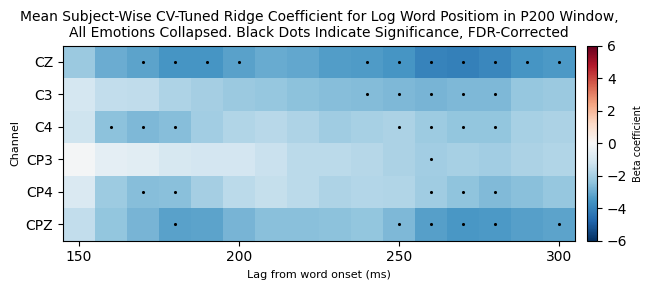

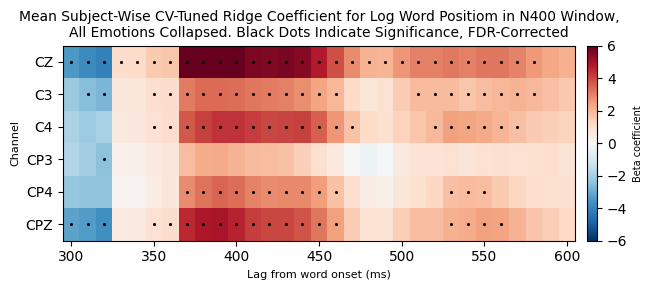

In [ ]:
subj_refit_r2s = [s.r2 for s in subj_refit]
subj_alphas = [float(s.best_alpha) for s in subj_alpha_tuned]
print(f"Refit per-subject R^2:\n  {subj_refit_r2s}")
print(f"Refit per-subject best alpha:\n  {subj_alphas}")

p200_coefs = get_time_window_coefs(subj_refit,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.15, 0.3),
                                   sfreq=100.0,
                                   sig_thresh=0.05)

n400_coefs = get_time_window_coefs(subj_refit,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.3, 0.6),
                                   sfreq=100.0,
                                   sig_thresh=0.05)

vmax = np.nanmax(np.abs(np.concatenate[p200_coefs.beta_window.mean(axis=0),
                                       n400_coefs.beta_window.mean(axis=0)]))
vmin = -vmax
fig1 = time_window_heatmap(p200_coefs,
                           time_window=(0.15, 0.3),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           vmin=vmin, vmax=vmax,
                           component_name="P200")
fig2 = time_window_heatmap(n400_coefs,
                           time_window=(0.3, 0.6),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           vmin=vmin, vmax=vmax,
                           component_name="N400")
plt.show()

In [41]:
def plot_waveforms(reconstruct: np.ndarray,
                   real_data: np.ndarray,
                   ch_roi: list, *,
                   decim: int,
                   figsize: tuple,
                   colors: list,
                   linewidth: float=0.75,
                   tick_labelsize: float=7.5,
                   xylabel_fontsize: float=10.5,
                   legend_bbox_to_anchor: list=[0.67, -0.06, 0.5, 0.5],
                   title_fontsize: float=13.0):
    assert reconstruct.shape == real_data.shape
    _, n_channels, n_times = reconstruct.shape
    assert len(ch_roi) == len(colors) == n_channels
    downsampled_times = np.linspace(0.0, n_times*decim, n_times)

    reconstruct_mean = np.mean(reconstruct, axis=0)
    real_data_mean = np.mean(real_data, axis=0)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)
    for (j, ch), color in zip(enumerate(ch_roi), colors):
        axes[0].plot(downsampled_times, reconstruct_mean[j, :], linewidth=linewidth, label=ch, color=color)
        axes[1].plot(downsampled_times, real_data_mean[j, :], linewidth=linewidth, label=ch, color=color)
        axes[0].set_title("Reconstructed ERPs with Deconvolution (Words 1-7)\nAll Emotion Categories Collapsed",
                           y=1.02, fontsize=title_fontsize)
        axes[1].set_title("Grand Average ERPs (Words 1-7)\nAll Emotion Categories Collapsed",
                           y=1.02, fontsize=title_fontsize)
    for ax in axes:   
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
        ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
        ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
    axes[1].legend(bbox_to_anchor=legend_bbox_to_anchor)
    axes[1].set_ylabel("uV", fontsize=xylabel_fontsize, x=0.05)
    axes[1].set_xlabel("Time (ms)", fontsize=xylabel_fontsize, y=0.05)
    axes[1].invert_yaxis()

    fig.tight_layout()
    plt.show()

    

In [15]:
reconstruct = np.array([subj_refit[i].pred for i in range(len(subj_refit))])
real_data = np.array([e.get_data(units="uV", picks=ch_roi) for e in list_of_evokeds])
print(reconstruct.shape)
print(real_data.shape)

(34, 6, 257)
(34, 6, 257)


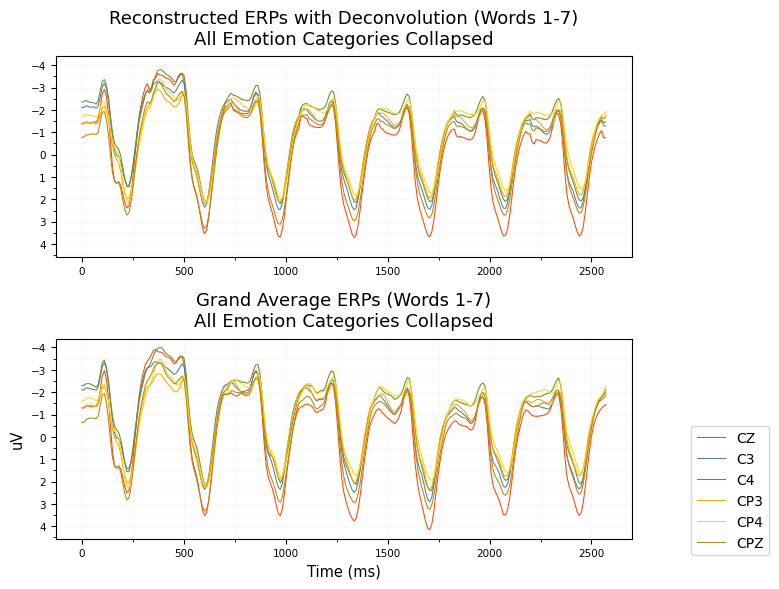

In [42]:
colors = ["orangered", "steelblue", "olivedrab", "orange", "gold", "darkgoldenrod"]
plot_waveforms(reconstruct,
               real_data,
               ch_roi,
               decim=10,
               figsize=(8, 6),
               colors=colors,
               linewidth=0.75,
               tick_labelsize=7.5,
               xylabel_fontsize=10.5,
               legend_bbox_to_anchor=[0.8, 0.15, 0.45, 0.45],
               title_fontsize=13.0)

### Separating emotion categories